<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex08_RNN_%EB%8B%A8%EC%96%B4%ED%95%99%EC%8A%B5%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# cpu
# 드라이브 연동 x
# CNN: 이미지 내부 특성 추출 특화된 모델
# RNN: 순환신경망, 학습을 위해서 반복적으로 순환하면서 데이터를 학습하는 모델
# -- 텍스트 데이터, 시계열 관련 처리하는 모델
# -- 시간에 따라 변하는, 문맥의 의미가 있는, 앞뒤 순서 개념을 가지는 데이터에 특화된 모델
# -- 순환: 앞에 대한 내용을 인식(학습)-> 이후에 오는 데이터의 맥락을 파악하는

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 목표
- simpleRNN 사용해보기
- 과거 4개의 알파벳을 기억하여, 다음 등장할 알파벳을 예측하는 모델을 만들어보기
        - hell > o
        - appl > e
        - 학습데이터: hello, apple, lobby, daddy, bobby

데이터 처리하기

In [ ]:
# 학습데이터: hello, apple, lobby, daddy, bobby
# 문자 데이터 이해하기
# 1. 토큰화: 데이터 쪼개는 작업(문자 단위, 어절단위, 형태소 단위)
# 2. 인코딩: 문자 -> 숫자

In [53]:
# char 문자 단위로 단어를 쪼개보자!!
# 원핫인코딩 수치화
# h, e, l, o, a, p, b, y, d (총 9개)
h = [1,0,0,0,0,0,0,0,0]
e = [0,1,0,0,0,0,0,0,0]
l = [0,0,1,0,0,0,0,0,0]
o = [0,0,0,1,0,0,0,0,0]
a = [0,0,0,1,0,0,0,0,0]
p = [0,0,0,0,0,1,0,0,0]
b = [0,0,0,0,0,0,1,0,0]
y = [0,0,0,0,0,0,0,1,0]
d = [0,0,0,0,0,0,0,0,1]

In [54]:
# X
# hell
# appl
# lobb
# dadd
# bobb
X = np.array([
    [h,e,l,l],
    [a,p,p,l],
    [l,o,b,b],
    [d,a,d,d],
    [b,o,b,b],
])

X.shape

# 글자 1개를 표현하기 위해서는 9개의 특성으로 표현되고 있음
# 글자의 개수를 통해서 순환 횟수 확인 가능!
# sample,timestep(순환횟수),features
# timestep: 정답으로 가기까지의 단계(횟수)

(5, 4, 9)

In [20]:
y_label = np.array([o,e,y,y,y])
y_label


array([[0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0]])

In [21]:
y_label.shape
# 2차원
# sample 5
# 각 단어를 표현하기 위해서 9개의 특성으로 수치화된 상황

(5, 9)

RNN 모델링

In [22]:
# 뼈대 구축
# 층 내용 정의
# rnn 기능
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [23]:
# model 뼈대 구축
model = Sequential()
# 입력층, 중간층
# 중간층 개념에 simpleRNN이 연결됨
# input_shape: 데이터 크기가 커짐 ex) 2차원 (8,16), 3차원(64,8,16)
# input_dim: 숫자 형태로 ex) 8, 9, 256
# input_shape: (4,9) -> (timestep, features)
# 이전 단어에 대한 기억을 순환하면서 전달하게 됨
# * 기존 모델 차이점: 순환하면서 기억할 수 있는 메모리 구조
model.add(SimpleRNN(units=2, input_shape=X[0].shape, activation='tanh'))
# 출력층
# 다중분류 문제: units=클래스의 개수, activation='softmax'
model.add(Dense(units=9, activation='softmax'))

# 정보요약
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 2)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(loss = 'categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

In [27]:
# 학습
# 문제, 답
# 반복횟수 1000
# h 변수 대입
# yolo (by pytorch) : 학습 train
# tensorflow: 학습 fit
h = model.fit(X, y_label, epochs=1000)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 2.2221
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.0000e+00 - loss: 2.2187
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.0000e+00 - loss: 2.2152
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.0000e+00 - loss: 2.2118
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0000e+00 - loss: 2.2083
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.0000e+00 - loss: 2.2048
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.0000e+00 - loss: 2.2014
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.0000e+00 - loss: 2.1979
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.0000e+00 - loss: 2.1944
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.0000e+00 - loss: 2.1910
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.0000e+00 - loss: 2.1875
Epoch 12/1000
1/1

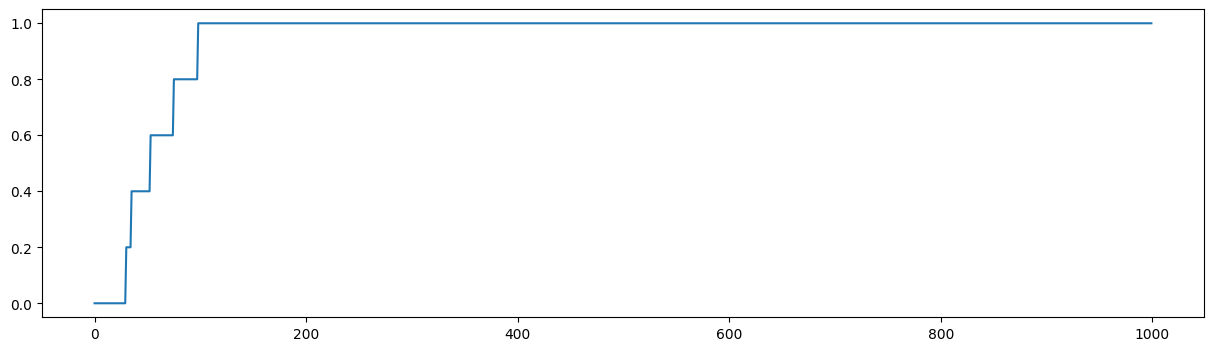

In [40]:
plt.figure(figsize=(15,4))
plt.plot(h.history['accuracy'])
plt.show() # 80%

In [57]:
#h -> e-> l -> l ==> o?
class_names = ['h','e','l','o','a','p','b','y','d']
pred = model.predict(np.array([[h,e,l,l]])) # hell -> 3차원 개념
pred

# 학습 시점 input_shape : (4,9)
# X : (5,4,9) 3차원

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[0.01380187, 0.08398541, 0.01331655, 0.7584704 , 0.01677556,
        0.01771771, 0.01725335, 0.04922382, 0.02945528]], dtype=float32)

In [58]:
np.argmax(pred[0]) # np.int64(3)
# 3번째 인덱스에 확률값이 제일 큼 -> 3이라고 예측한 것
print(class_names)

['h', 'e', 'l', 'o', 'a', 'p', 'b', 'y', 'd']
